# Summary

**Data.** SIPRI arms transfer register, 1950–2024 (28,724 deals after cleaning).
Edges are directed supplier → recipient, binarised per deal. Non-state actors and
"unknown" entries are dropped.

We changed records belonging to "Russia" pre-2024 to "Soviet Union" for consistency. We created 15 5-year window bins for the deals
We analyse two window sets: `ALL_WINDOWS` (all fifteen, for the multilayer
stage) and `KEY_WINDOWS` (1960–64, 1980–84, 1995–99, 2020–24), chosen as
structurally distinct regimes that each sit on one side of the 1991 dissolution.

**What we've done so far:**

1. We plotted graphs using undirected binary graphs for community detection and directed graphs used only for in/out-degree.
2. We completed some exploratory analysis of the four key windows (under stage A). Per window we report
  connectivity metrics (density, components, clustering, average path length),
  a Louvain resolution sweep, k-cores, and top exporters/importers. We compare
  Louvain, Walktrap, and Edge Betweenness as a robustness check.
3. We conducted multilayer temporal community detection (under stage B)
  Joint partition across all fifteen slices with an interslice weight, plus a
  bloc-membership-over-time heatmap

**Issues encountered**

1. The data presents weak community structure. Modularity appears low across the key windows
   (Louvain ≈ 0.23–0.35), and the resolution sweep does not plateau except at the
   degenerate two-group split (γ ≈ 0.5–0.75). The only window with clearly
   elevated modularity is in early Cold War (1960–64), where a genuine
   Soviet bloc is recovered. We currently default to γ = 1.0 pragmatically.
2. The data has a core-periphery structure. Degree distributions show a star-like shape. The network seem to be organised more by
   supplier vs recipient than by bounded blocs, so it may sit closer to a
   positional / core-periphery problem than a community-detection one. We would like some
   guidance on whether to explore stochastic block model or perhaps core-periphery model?
3. The methods disagree disagree substantially on the same window
   (e.g. 2020–24: Louvain 5, Walktrap 32, Edge Betweenness 116 communities),
   reinforcing that the structure is weak rather than that one method is right.

In [32]:
!pip install leidenalg
import pandas as pd
import igraph as ig
import leidenalg as la
from collections import Counter

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving trade-register.csv to trade-register.csv


## Data preparation

The following are computed using the year of the deal's conclusion.

In [ ]:
df = pd.read_csv("trade-register.csv", skiprows=11, encoding="latin-1")
df.columns = df.columns.str.strip()

df = df[["Recipient", "Supplier", "Year of order",
         "SIPRI TIV of delivered weapons"]].copy()
df.columns = ["recipient", "supplier", "year", "tiv"]

df = df.dropna(subset=["recipient", "supplier", "year"])

Excluded non-state actors, following the approach of Lebacher et al. (2021):

In [33]:
# Drop non-state actors (marked "*") and unknown
df = df[~df["recipient"].str.endswith("*")]
df = df[~df["supplier"].str.endswith("*")]
df = df[~df["recipient"].str.contains("unknown", case=False, na=False)]
df = df[~df["supplier"].str.contains("unknown", case=False, na=False)]

In [ ]:
# drop NA
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

In [ ]:
# 2025 incomplete, 1940s only a few deals
df = df[(df["year"] >= 1950) & (df["year"] <= 2024)]

In [ ]:
# Some pre-1992 deals are recorded under "Russia" although the USSR still existed.
mask = (df["supplier"] == "Russia") & (df["year"] < 1992)
df.loc[mask, "supplier"] = "Soviet Union"
mask = (df["recipient"] == "Russia") & (df["year"] < 1992)
df.loc[mask, "recipient"] = "Soviet Union"

Split the data into five-year windows to create the temporal layers which we use to track how the network's community structure changes over time:

In [ ]:
def window_label(year):
    start = (year // 5) * 5
    return f"{start}-{start + 4}"
df["window"] = df["year"].apply(window_label)

**ALL_WINDOWS**: fifteen 5-year windows covering SIPRI's full period (1950-2024), used for multilayer analysis.

**KEY_WINDOWS**: four windows for in-depth exploratory analysis, chosen as structurally distinct regimes of the arms trade system:

- 1960-1964  mature bipolar Cold War
- 1980-1984  late Cold War, last stable bipolar regime
- 1995-1999  post-Soviet reconfiguration (the 1990-94 transition is skipped)
- 2020-2024  contemporary multipolar structure

None of these windows crosses the 1991 dissolution, so the set of actors in each is unambiguous.

In [ ]:
ALL_WINDOWS = [f"{s}-{s+4}" for s in range(1950, 2021, 5)]
KEY_WINDOWS = ["1960-1964", "1980-1984", "1995-1999", "2020-2024"]

print("rows:", len(df), "| years:", df["year"].min(), "-", df["year"].max())

rows: 28724 | years: 1950 - 2024


## Graphs

In [ ]:
def edge_set(data, window):
    """Directed (supplier -> recipient) pairs, binary, no self-loops."""
    sub = data[data["window"] == window]
    return {(s, r) for s, r in zip(sub["supplier"], sub["recipient"]) if s != r}

In [ ]:
def build_undirected(data, window):
    """Undirected binary graph for community detection."""
    und = {tuple(sorted(p)) for p in edge_set(data, window)}
    countries = sorted({c for p in und for c in p})
    g = ig.Graph()
    g.add_vertices(countries)
    g.add_edges(list(und))
    return g

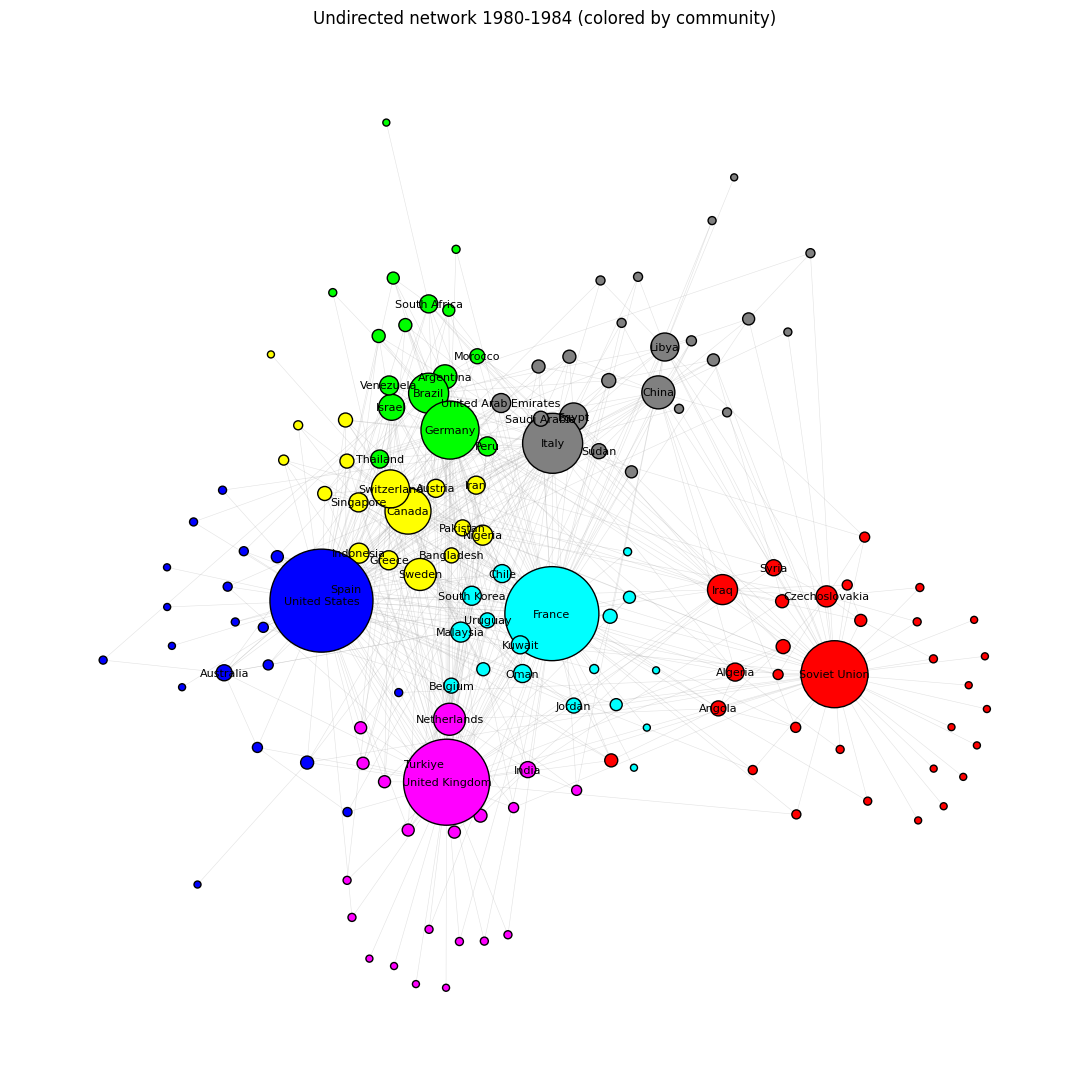

In [ ]:
import matplotlib.pyplot as plt

# ---------- Visualization of build_undirected: communities ----------
def plot_undirected(data, window, resolution=1.0):
    g = build_undirected(data, window)
    part = g.community_multilevel(resolution=resolution)
    # weight intra-community edges higher so blocks pull apart -> readable
    w = [4.0 if part.membership[e.source] == part.membership[e.target] else 0.3
         for e in g.es]
    layout = g.layout_fruchterman_reingold(weights=w, niter=1500)
    deg = g.degree()
    fig, ax = plt.subplots(figsize=(11, 11))
    ig.plot(part, target=ax, layout=layout,
            vertex_size=[6 + 1.2*d for d in deg],
            vertex_label=[n if deg[i] >= 8 else "" for i, n in enumerate(g.vs["name"])],
            vertex_label_size=8,
            edge_color="rgba(160,160,160,0.3)", edge_width=0.4)
    ax.set_title(f"Undirected network {window} (colored by community)")
    plt.tight_layout(); plt.show()

plot_undirected(df, "1980-1984")

In [ ]:
def build_directed(data, window):
    """Directed binary graph (used only for in/out-degree)."""
    directed = edge_set(data, window)
    countries = sorted({c for p in directed for c in p})
    g = ig.Graph(directed=True)
    g.add_vertices(countries)
    g.add_edges(list(directed))
    return g

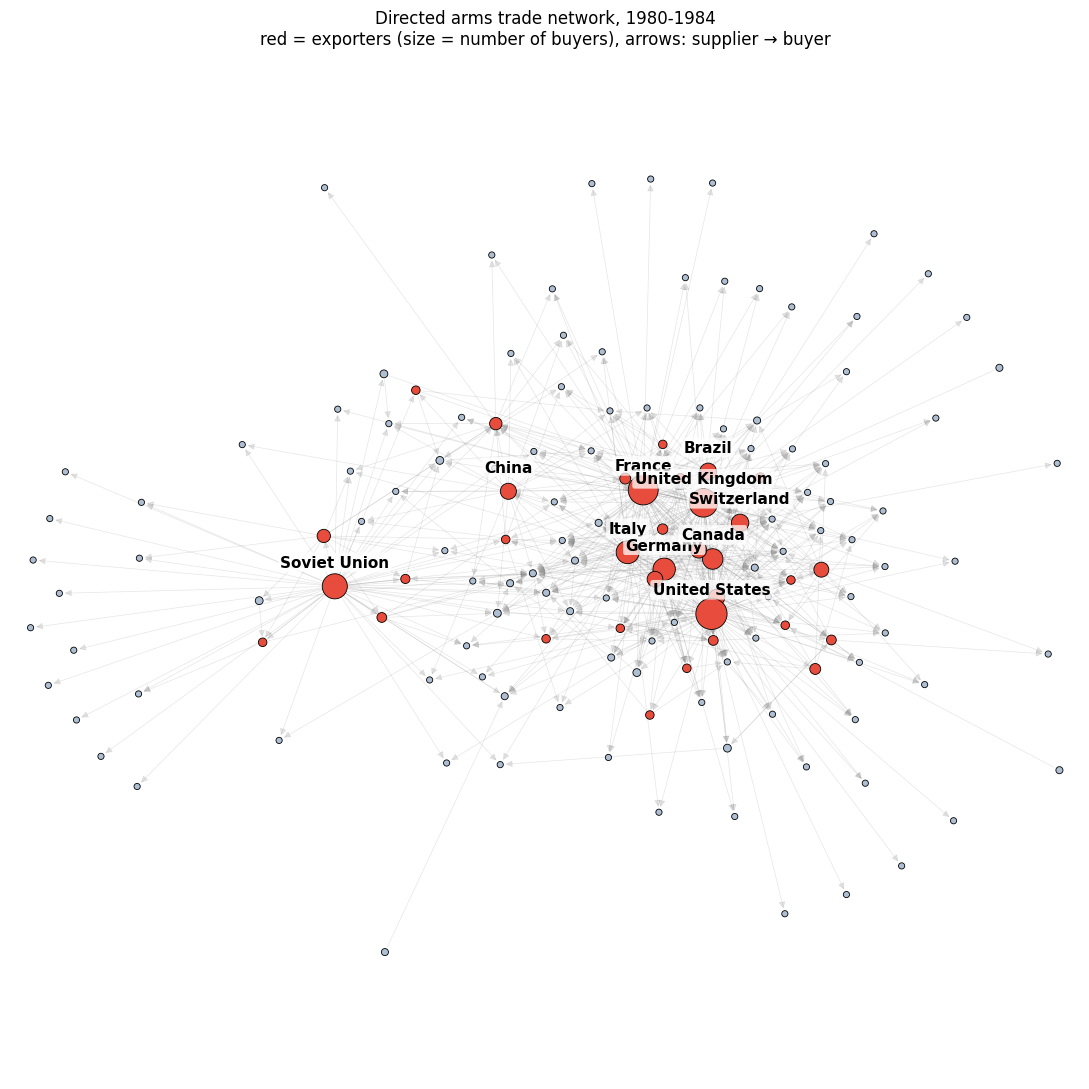

In [ ]:
import matplotlib.pyplot as plt

def plot_directed(data, window, label_top=10):
    g = build_directed(data, window)
    outd = g.outdegree()
    colors = ["#e74c3c" if outd[i] >= 3 else "#aebfd4" for i in range(g.vcount())]
    sizes  = [20 + 6.0*outd[i] for i in range(g.vcount())]      # node size
    layout = g.layout_fruchterman_reingold(niter=3000)
    coords = layout.coords
    xs = [c[0] for c in coords]; ys = [c[1] for c in coords]

    fig, ax = plt.subplots(figsize=(11, 11))
    for e in g.es:
        x0, y0 = coords[e.source]; x1, y1 = coords[e.target]
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle="-|>", color="gray",
                                    alpha=0.2, lw=0.5, shrinkA=4, shrinkB=4))
    ax.scatter(xs, ys, s=sizes, c=colors, edgecolors="black", linewidths=0.6, zorder=3)
    top = sorted(range(g.vcount()), key=lambda i: -outd[i])[:label_top]
    for i in top:
        if outd[i] > 0:
            ax.text(xs[i], ys[i]+0.25, g.vs[i]["name"], fontsize=11,
                    ha="center", va="bottom", fontweight="bold", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))
    # zoom in around the points
    mx = (max(xs)+min(xs))/2; my = (max(ys)+min(ys))/2
    span = max(max(xs)-min(xs), max(ys)-min(ys)) * 0.52
    ax.set_xlim(mx-span, mx+span); ax.set_ylim(my-span, my+span)
    ax.set_title(f"Directed arms trade network, {window}\n"
                 f"red = exporters (size = number of buyers), arrows: supplier → buyer", fontsize=12)
    ax.axis("off"); plt.tight_layout(); plt.show()

plot_directed(df, "1980-1984")

## Analysis functions

Overview:

1. Exploratory analysis: four structurally distinct windows (1960–64, 1980–84, 1995–99, 2020–24), each examined with connectivity measures, Louvain with a resolution sweep, and k-cores. We compare methods to check robustness: we report Louvain and Walktrap but drop Edge Betweenness, which over-fragments.
2. Multilayer Leiden analysis: temporal community detection across all 15 windows (Mucha et al. 2010) to track how subgroups form, persist, and reorganise from 1950 to 2024.

In [ ]:
def basic_metrics(g):
    comps = g.connected_components()
    giant = comps.giant()
    print(f"  density:          {g.density():.4f}")
    print(f"  components:       {len(comps)} (largest: {giant.vcount()})")
    print(f"  clustering:       {g.transitivity_undirected():.3f}")
    print(f"  avg path (giant): {giant.average_path_length():.2f}")

In [ ]:
def louvain_sweep(g, resolutions):
    print("  resolution -> number of communities:")
    for r in resolutions:
        p = g.community_multilevel(resolution=r)
        print(f"    {r:.2f} -> {len(p)}")

In [ ]:
def three_methods(g, resolution):
    louvain  = g.community_multilevel(resolution=resolution)   # modularity
    walktrap = g.community_walktrap().as_clustering()          # diffusion
    eb       = g.community_edge_betweenness().as_clustering()  # divisive
    print(f"  Louvain:          {len(louvain)} comms (modularity {louvain.modularity:.3f})")
    print(f"  Walktrap:         {len(walktrap)} comms (modularity {walktrap.modularity:.3f})")
    print(f"  Edge betweenness: {len(eb)} comms (modularity {eb.modularity:.3f})")
    return louvain, walktrap, eb

Spectral methods is not used as they tend to underperform on small-to-medium networks, which is the size of our windows (~120-160 countries).

In [ ]:
def show_communities(g, partition, min_size=4):
    for i, comm in enumerate(partition):
        names = [g.vs[v]["name"] for v in comm]
        if len(names) >= min_size:
            print(f"    Community {i} ({len(names)}): {', '.join(names)}")

In [ ]:
def k_cores(g, top=8):
    cores = g.coreness()
    ranked = sorted(zip(g.vs["name"], cores), key=lambda x: -x[1])
    print("  Core (top coreness): " +
          ", ".join(f"{n}(k={c})" for n, c in ranked[:top]))

In [ ]:
def direction_summary(data, window, top=6):
    """Direction kept descriptively: top exporters / importers."""
    gd = build_directed(data, window)
    outd = sorted(zip(gd.vs["name"], gd.outdegree()), key=lambda x: -x[1])
    ind  = sorted(zip(gd.vs["name"], gd.indegree()),  key=lambda x: -x[1])
    print("  Top exporters (out-degree): " +
          ", ".join(f"{n}({d})" for n, d in outd[:top] if d > 0))
    print("  Top importers (in-degree):  " +
          ", ".join(f"{n}({d})" for n, d in ind[:top] if d > 0))

In [ ]:
def analyze_window(data, window, resolution=1.0):
    g = build_undirected(data, window)
    print(f"\n=== WINDOW {window} ===")
    basic_metrics(g)
    louvain_sweep(g, [0.5, 0.75, 1.0, 1.25, 1.5])
    lv, wt, eb = three_methods(g, resolution)
    print("  Communities (Louvain):")
    show_communities(g, lv)
    k_cores(g)
    direction_summary(data, window)
    return g, lv

## STAGE A: in-depth analysis of key windows

In [ ]:
for w in KEY_WINDOWS:
    analyze_window(df, w, resolution=1.0)


=== WINDOW 1960-1964 ===
  density:          0.0452
  components:       1 (largest: 120)
  clustering:       0.148
  avg path (giant): 2.44
  resolution -> number of communities:
    0.50 -> 2
    0.75 -> 3
    1.00 -> 5
    1.25 -> 7
    1.50 -> 9
  Louvain:          5 comms (modularity 0.352)
  Walktrap:         2 comms (modularity 0.233)
  Edge betweenness: 42 comms (modularity 0.191)
  Communities (Louvain):
    Community 0 (26): Afghanistan, Albania, Algeria, Bulgaria, China, Cuba, Czechoslovakia, East Germany (GDR), Egypt, Ethiopia, Guinea, Hungary, India, Indonesia, Mali, Mongolia, Morocco, Myanmar, North Korea, Poland, Romania, Somalia, Soviet Union, Syria, Viet Nam, Yugoslavia
    Community 1 (25): Argentina, Brazil, Brunei, Cameroon, Canada, Ghana, Iraq, Jamaica, Jordan, Kenya, Kuwait, Lebanon, Libya, Malawi, Mexico, Nepal, Oman, Paraguay, Peru, Saudi Arabia, Trinidad and Tobago, United Kingdom, Venezuela, Zambia, Zimbabwe
    Community 2 (26): Australia, Austria, Chile, Col

### Visualisation

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

def plot_blocks(data, window, resolution=1.0):
    g = build_undirected(data, window)
    part = g.community_multilevel(resolution=resolution)
    deg = g.degree()

    # Pull communities apart: intra-community edges get higher layout weight.
    w = [5.0 if part.membership[e.source] == part.membership[e.target]
         else 0.3 for e in g.es]
    layout = g.layout_fruchterman_reingold(weights=w, niter=2000)
    coords = layout.coords
    xs = [c[0] for c in coords]; ys = [c[1] for c in coords]

    palette = plt.get_cmap("tab10")
    big = [cid for cid, sz in Counter(part.membership).items() if sz >= 5]
    cmap = {cid: palette(i % 10) for i, cid in enumerate(big)}
    node_colors = [cmap.get(c, (0.8, 0.8, 0.8, 1)) for c in part.membership]
    node_sizes = [40 + 18 * d for d in deg]

    fig, ax = plt.subplots(figsize=(13, 13))
    for e in g.es:
        x0, y0 = coords[e.source]; x1, y1 = coords[e.target]
        same = part.membership[e.source] == part.membership[e.target]
        ax.plot([x0, x1], [y0, y1], color="gray",
                alpha=0.25 if same else 0.06, lw=0.4, zorder=1)
    ax.scatter(xs, ys, s=node_sizes, c=node_colors,
               edgecolors="black", linewidths=0.4, zorder=2)
    thr = sorted(deg, reverse=True)[min(18, len(deg) - 1)]
    for i, name in enumerate(g.vs["name"]):
        if deg[i] >= thr:
            ax.text(xs[i], ys[i], name, fontsize=8, ha="center",
                    va="center", fontweight="bold", zorder=3)
    ax.set_title(f"Arms trade communities, {window} "
                 f"(node size = number of partners; modularity {part.modularity:.2f})",
                 fontsize=13)
    ax.axis("off")
    handles = [mpatches.Patch(color=cmap[cid],
               label=f"Community {cid} (n={Counter(part.membership)[cid]})")
               for cid in big]
    ax.legend(handles=handles, loc="upper left", fontsize=9, framealpha=0.9)
    plt.tight_layout(); plt.show()

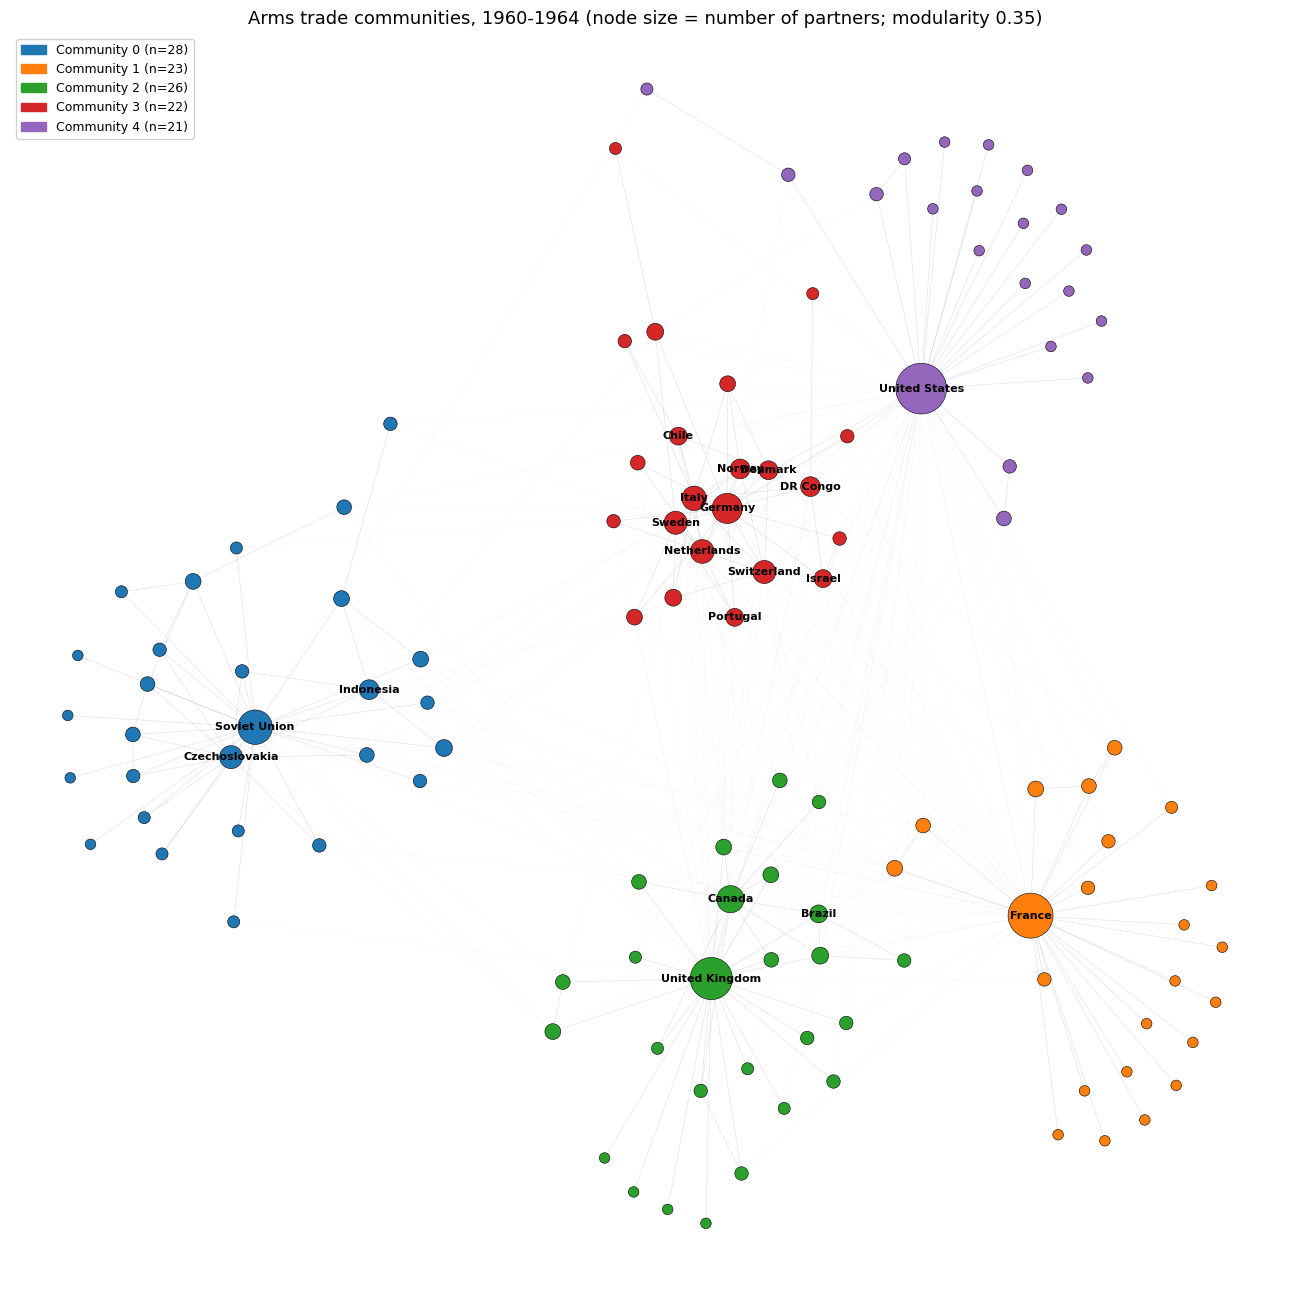

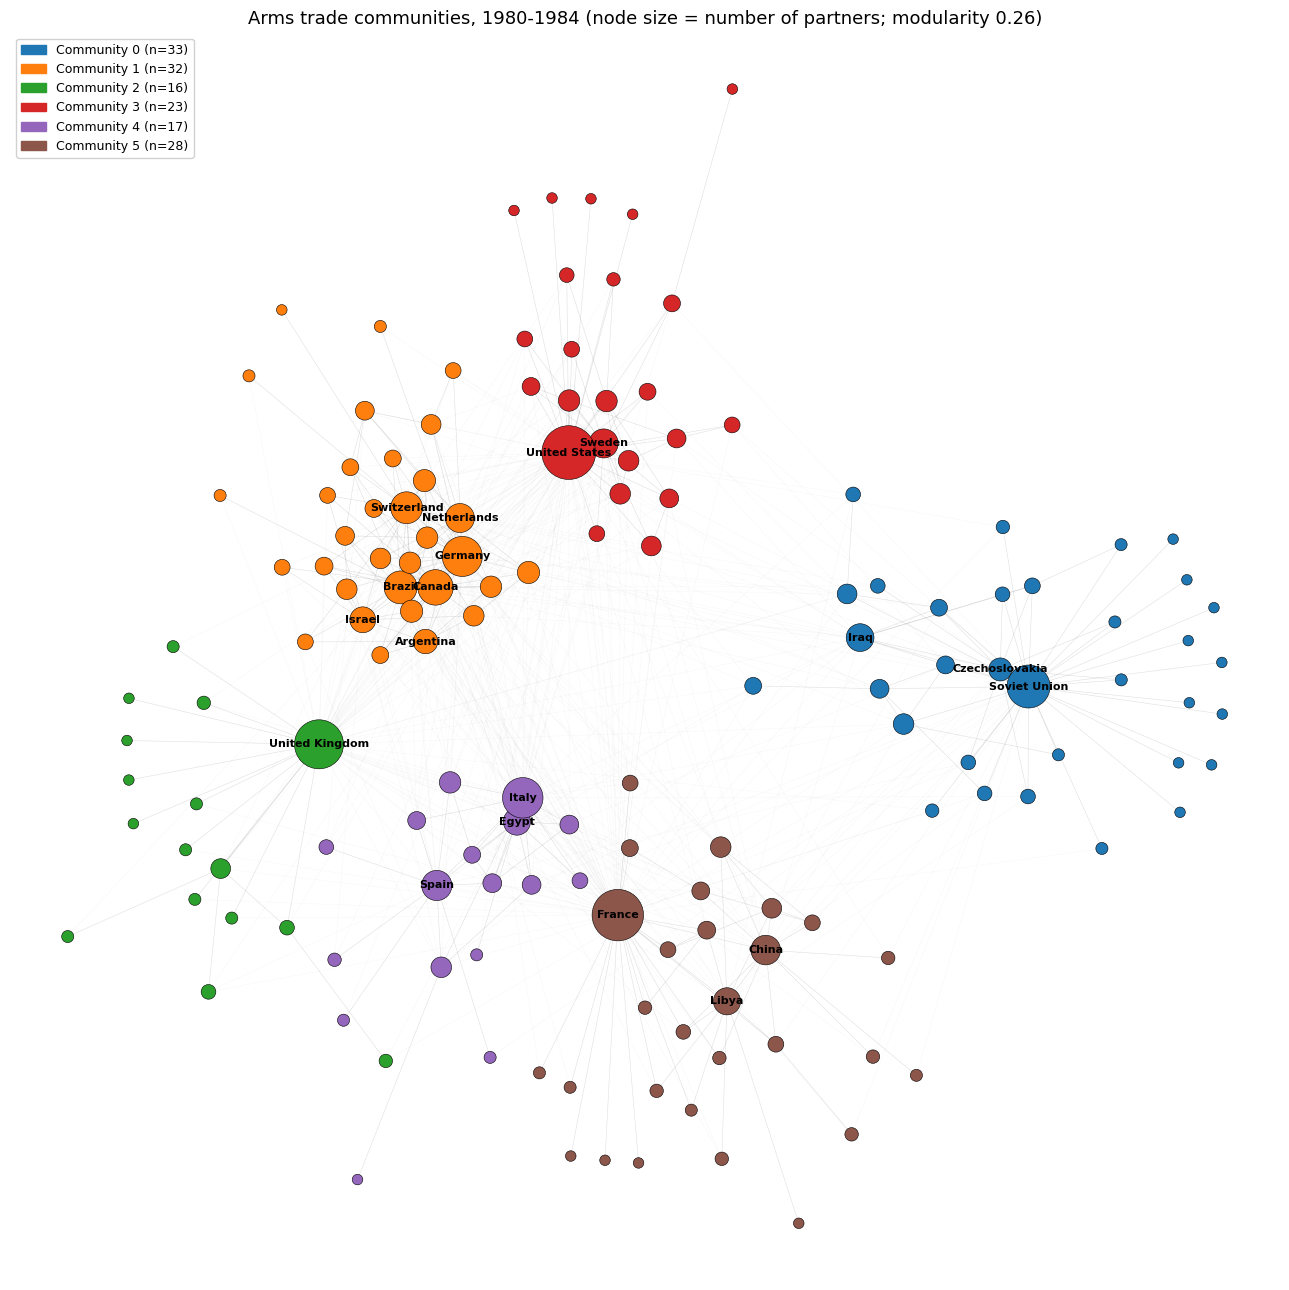

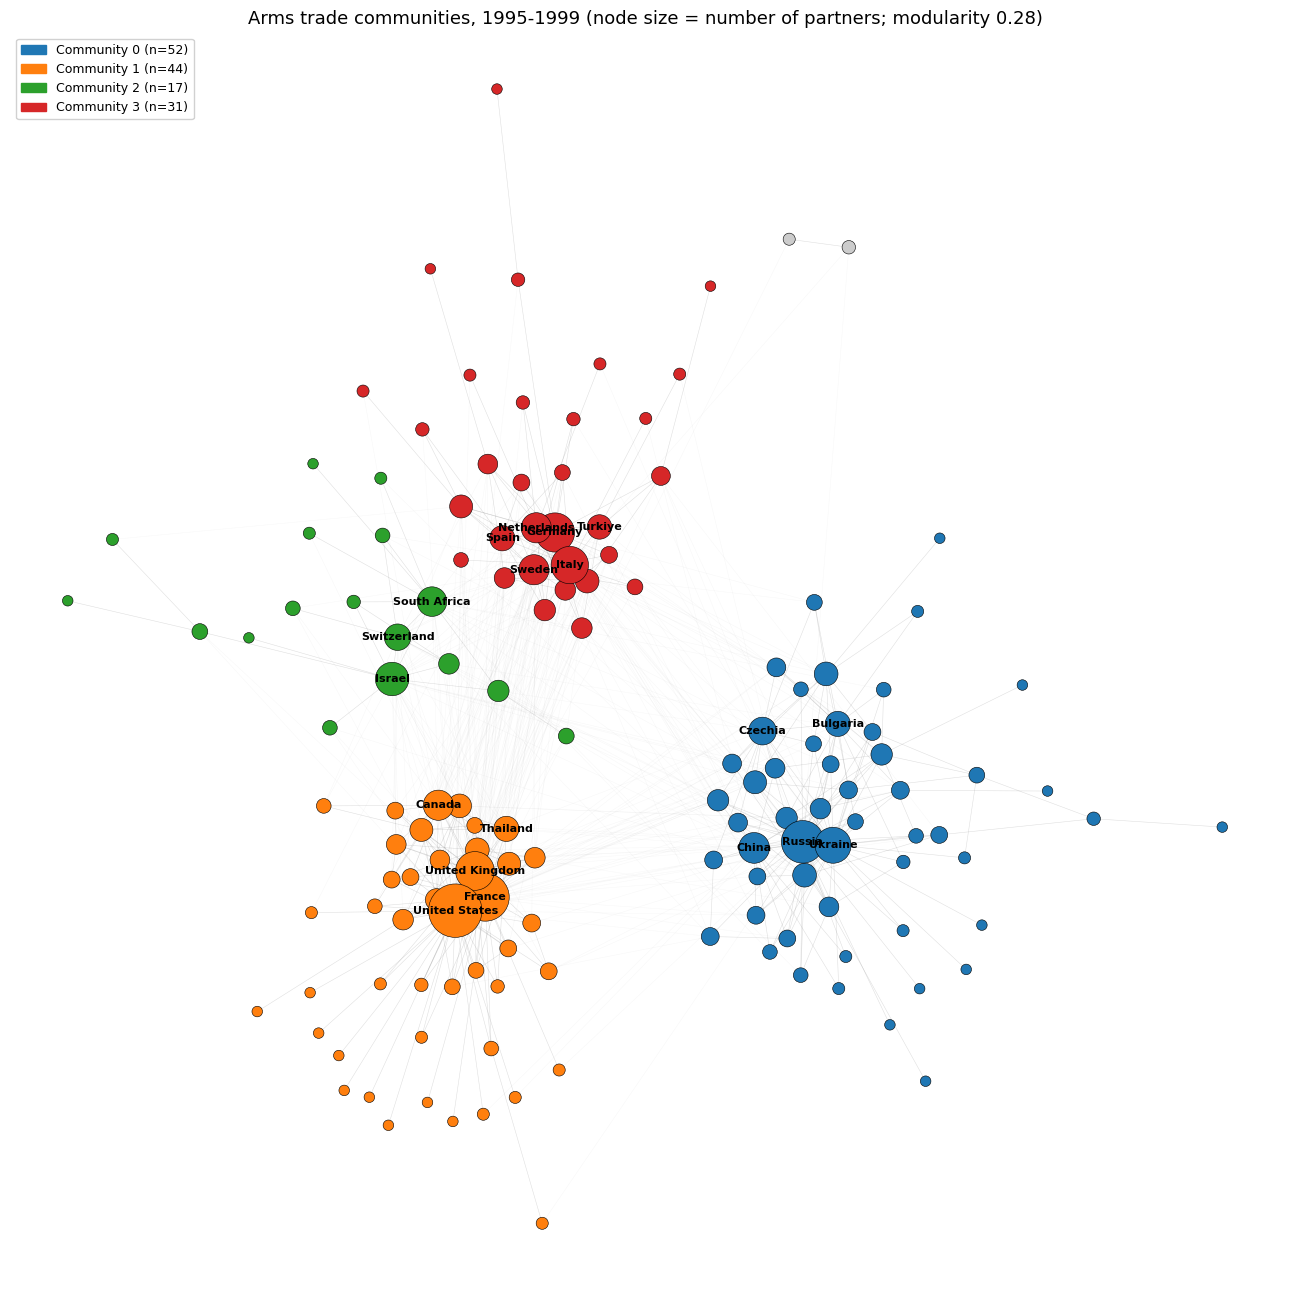

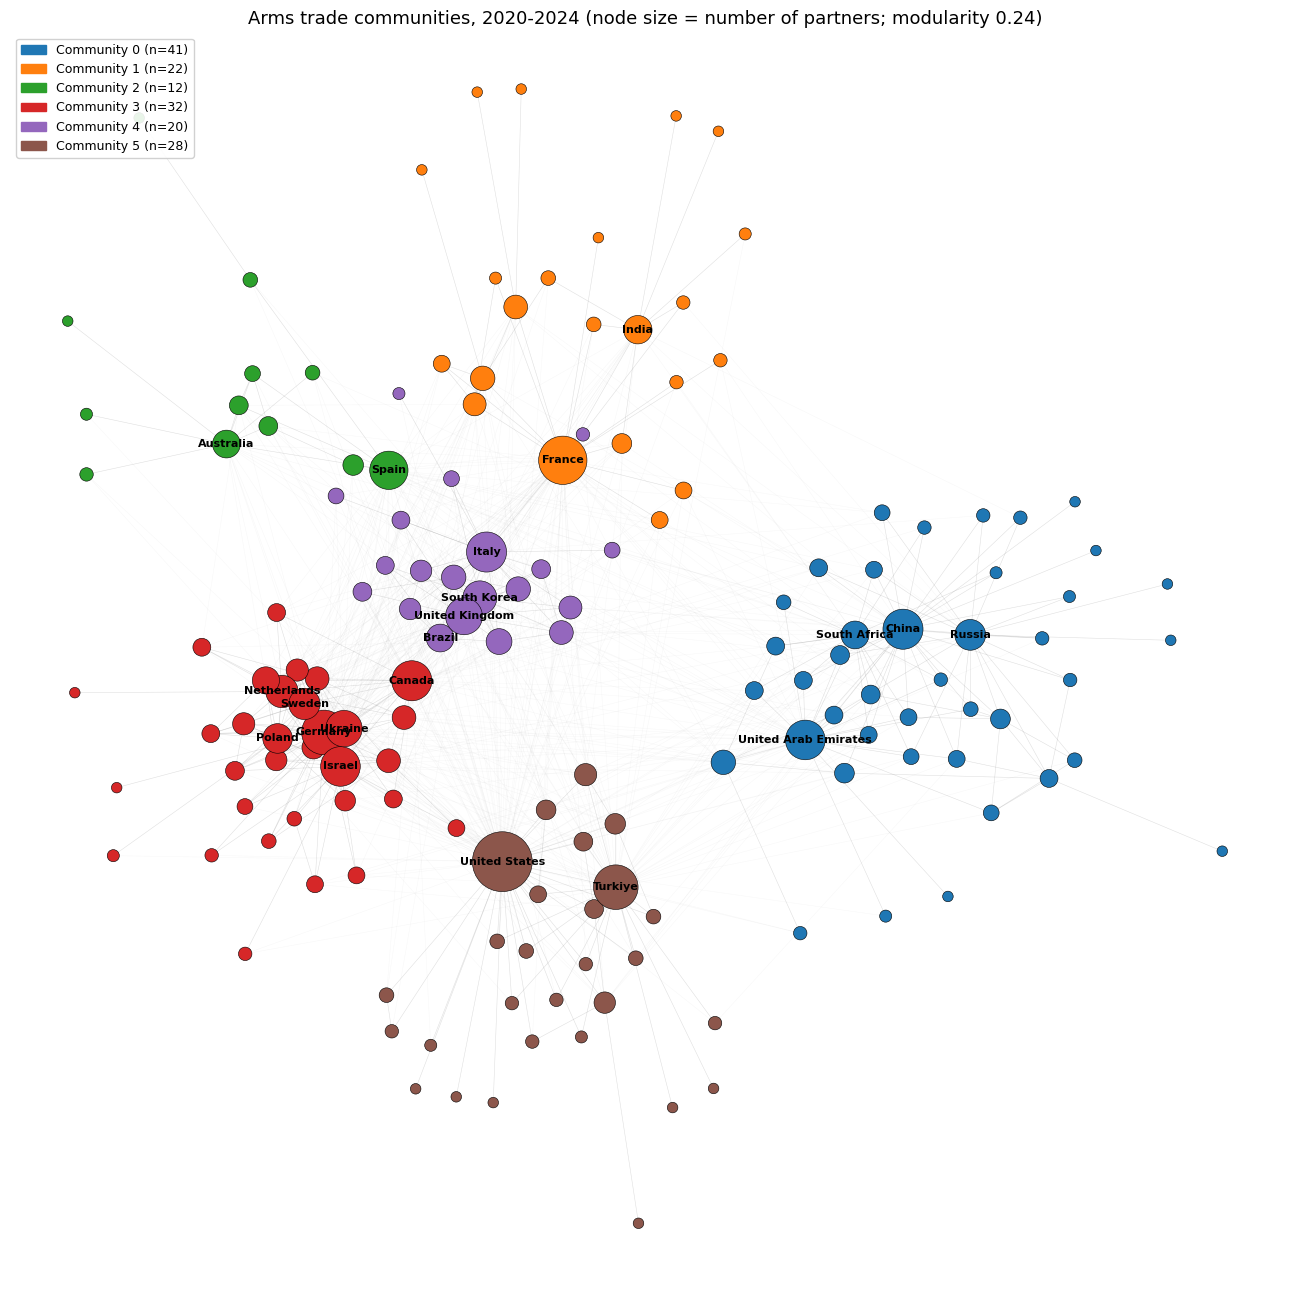

In [ ]:
plot_blocks(df, "1960-1964")
plot_blocks(df, "1980-1984")
plot_blocks(df, "1995-1999")
plot_blocks(df, "2020-2024")

## STAGE B: multilayer temporal community detection

In [ ]:
def run_multilayer(data, windows, resolution=1.0, interslice=0.5):
    graphs = [build_undirected(data, w) for w in windows]
    membership, improv = la.find_partition_temporal(
        graphs,
        la.RBConfigurationVertexPartition,
        interslice_weight=interslice,     # how sticky communities are over time
        resolution_parameter=resolution,  # community granularity
        vertex_id_attr="name",            # match the same country across slices
        n_iterations=2,
    )
    return graphs, membership

In [ ]:
graphs, membership = run_multilayer(df, ALL_WINDOWS, resolution=1.0, interslice=0.5)
n_comms = len({c for slice_m in membership for c in slice_m})
print(f"\n=== MULTILAYER: {n_comms} communities across {len(ALL_WINDOWS)} slices ===")
for idx, w in enumerate(ALL_WINDOWS):
    m = membership[idx]
    biggest = Counter(m).most_common(1)[0][1]
    print(f"  {w}: {len(set(m))} comms, largest = {biggest} countries")


=== MULTILAYER: 9 communities across 15 slices ===
  1950-1954: 5 comms, largest = 28 countries
  1955-1959: 5 comms, largest = 24 countries
  1960-1964: 5 comms, largest = 28 countries
  1965-1969: 6 comms, largest = 32 countries
  1970-1974: 6 comms, largest = 38 countries
  1975-1979: 6 comms, largest = 45 countries
  1980-1984: 5 comms, largest = 46 countries
  1985-1989: 5 comms, largest = 36 countries
  1990-1994: 5 comms, largest = 57 countries
  1995-1999: 4 comms, largest = 64 countries
  2000-2004: 5 comms, largest = 42 countries
  2005-2009: 5 comms, largest = 56 countries
  2010-2014: 5 comms, largest = 56 countries
  2015-2019: 6 comms, largest = 44 countries
  2020-2024: 7 comms, largest = 48 countries


In [ ]:
idx = ALL_WINDOWS.index("1980-1984")
for cid in set(membership[idx]):
    members = [graphs[idx].vs[v]["name"]
               for v in range(graphs[idx].vcount()) if membership[idx][v] == cid]
    print(cid, members)

0 ['Argentina', 'Austria', 'Belgium', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Comoros', 'Costa Rica', 'Denmark', 'Dominican Republic', 'Ecuador', 'Gabon', 'Germany', 'Guatemala', 'Honduras', 'Indonesia', 'Israel', 'Jamaica', 'Lesotho', 'Liberia', 'Luxembourg', 'Mexico', 'Morocco', 'Myanmar', 'Panama', 'Paraguay', 'Peru', 'Saint Kitts and Nevis', 'South Africa', 'South Korea', 'Spain', 'Switzerland', 'Tunisia', 'United Arab Emirates', 'United States', 'Uruguay', 'Venezuela']
1 ['Afghanistan', 'Algeria', 'Angola', 'Bulgaria', 'Burkina Faso', 'Cabo Verde', 'Cambodia', 'Central African Republic', 'China', 'Congo', 'Cuba', 'Czechoslovakia', 'East Germany (GDR)', 'Equatorial Guinea', 'Ethiopia', 'Grenada', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Hungary', 'India', 'Iran', 'Iraq', 'Jordan', 'Laos', 'Lebanon', 'Libya', 'Madagascar', 'Mali', 'Malta', 'Mongolia', 'Mozambique', 'Nicaragua', 'North Korea', 'North Yemen', 'Poland', 'Romania', 'Serbia', 'Seychelles', 'South Yemen', 'Soviet Union', 

### Visualisation

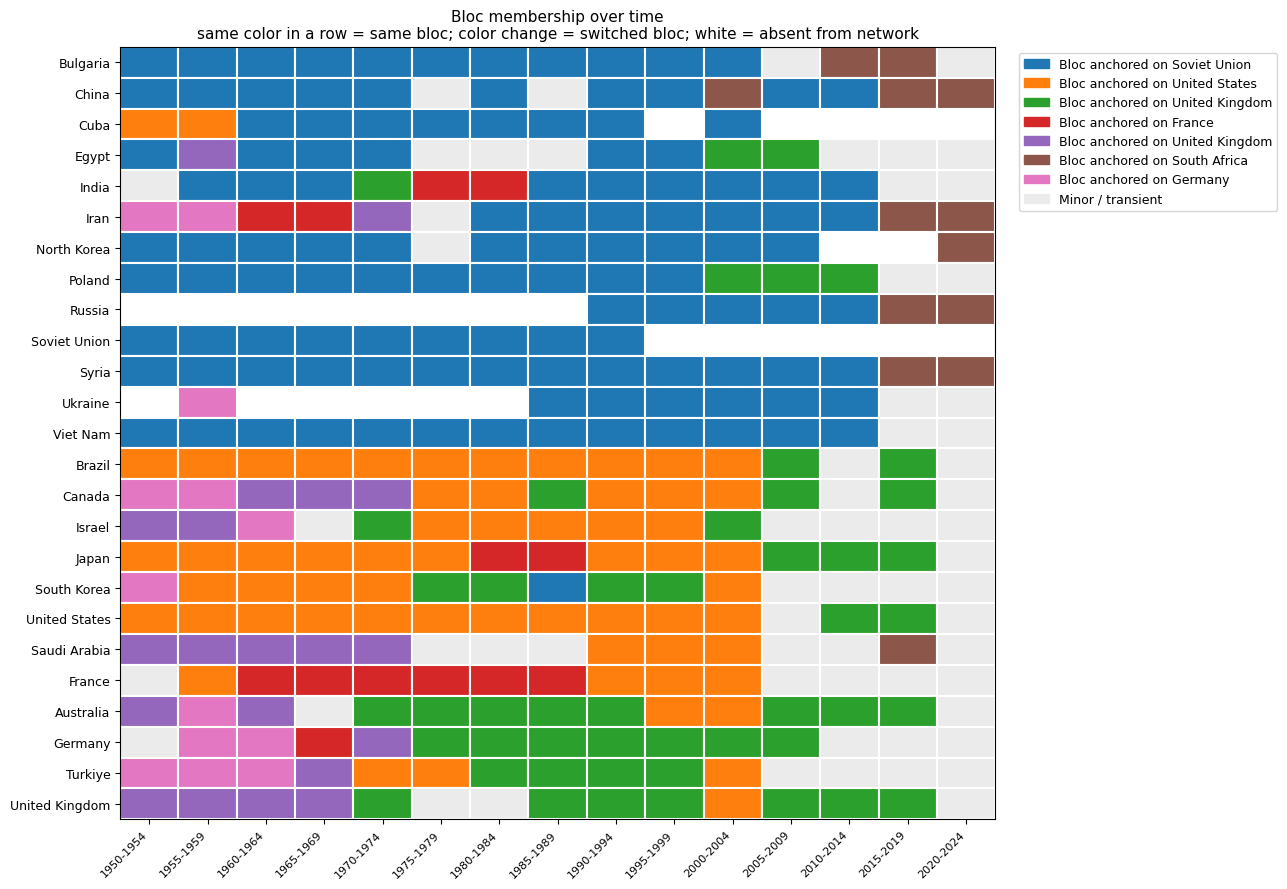

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import defaultdict, Counter

# run multilayer (seeded for reproducibility)
graphs = [build_undirected(df, w) for w in ALL_WINDOWS]
membership, _ = la.find_partition_temporal(
    graphs, la.RBConfigurationVertexPartition,
    interslice_weight=0.5, resolution_parameter=1.0,
    vertex_id_attr="name", n_iterations=2, seed=42)

# stitch community ids across slices by Jaccard overlap
comms = [defaultdict(set) for _ in ALL_WINDOWS]
for j, g in enumerate(graphs):
    for v in range(g.vcount()):
        comms[j][membership[j][v]].add(g.vs[v]["name"])
jac = lambda a, b: len(a & b) / len(a | b) if a | b else 0
gid, nxt = {}, 0
for c in comms[0]: gid[(0, c)] = nxt; nxt += 1
for j in range(1, len(ALL_WINDOWS)):
    for c, mem in comms[j].items():
        b = max(comms[j-1].items(), key=lambda kv: jac(mem, kv[1]), default=(None, set()))
        gid[(j, c)] = gid[(j-1, b[0])] if b[0] is not None and jac(mem, b[1]) >= 0.3 else nxt
        if gid[(j, c)] == nxt: nxt += 1

# name major lineages by their dominant hub (mechanical)
lineage = defaultdict(Counter)
slices_of = defaultdict(set)
for j, g in enumerate(graphs):
    deg = dict(zip(g.vs["name"], g.degree()))
    for v in range(g.vcount()):
        gg = gid[(j, membership[j][v])]
        lineage[gg][g.vs[v]["name"]] += deg[g.vs[v]["name"]]
        slices_of[gg].add(j)
major = sorted([g for g in slices_of if len(slices_of[g]) >= 3], key=lambda g: -len(slices_of[g]))
hub = {g: lineage[g].most_common(1)[0][0] for g in major}

# countries to show
track = ["United States","United Kingdom","France","Germany","Canada","Japan",
         "South Korea","Australia","Israel","Brazil","Soviet Union","Russia",
         "China","Ukraine","Poland","Bulgaria","Cuba","North Korea","Viet Nam",
         "India","Egypt","Iran","Syria","Saudi Arabia","Turkiye"]

# matrix + colors
palette = plt.get_cmap("tab10")
color_for = {g: palette(i % 10) for i, g in enumerate(major)}
M = np.full((len(track), len(ALL_WINDOWS)), -1)
for j, g in enumerate(graphs):
    n2c = {g.vs[v]["name"]: membership[j][v] for v in range(g.vcount())}
    for i, c in enumerate(track):
        if c in n2c: M[i, j] = gid[(j, n2c[c])]

# order rows by dominant lineage so similar trajectories sit together
def dom(i):
    vals = [M[i, j] for j in range(len(ALL_WINDOWS)) if M[i, j] != -1]
    return Counter(vals).most_common(1)[0][0] if vals else 999
order = sorted(range(len(track)), key=lambda i: (dom(i), track[i]))
track = [track[i] for i in order]; M = M[order]

# --- plot ---
fig, ax = plt.subplots(figsize=(13, 9))
for i in range(len(track)):
    for j in range(len(ALL_WINDOWS)):
        if M[i, j] == -1: continue
        col = color_for.get(M[i, j], (0.92, 0.92, 0.92, 1))
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, facecolor=col,
                                   edgecolor="white", lw=1.5))
ax.set_xlim(-0.5, len(ALL_WINDOWS)-0.5); ax.set_ylim(len(track)-0.5, -0.5)
ax.set_xticks(range(len(ALL_WINDOWS))); ax.set_xticklabels(ALL_WINDOWS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(track))); ax.set_yticklabels(track, fontsize=9)
ax.set_title("Bloc membership over time\nsame color in a row = same bloc; "
             "color change = switched bloc; white = absent from network", fontsize=11)
handles = [mpatches.Patch(color=color_for[g], label=f"Bloc anchored on {hub[g]}") for g in major]
handles.append(mpatches.Patch(color=(0.92,0.92,0.92,1), label="Minor / transient"))
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

## Issues encountered


We use degree distribution plot and resolution sweep to assess our data and see that there is an imbalance between exporters and importers, which makes sense but is not handled well by our methods. Additionally, the resolution sweep never plateaus, which means our community structure detected is not stable. These 2 outcomes, and low modularity, summarize our concerns.

### Degree distribution plot

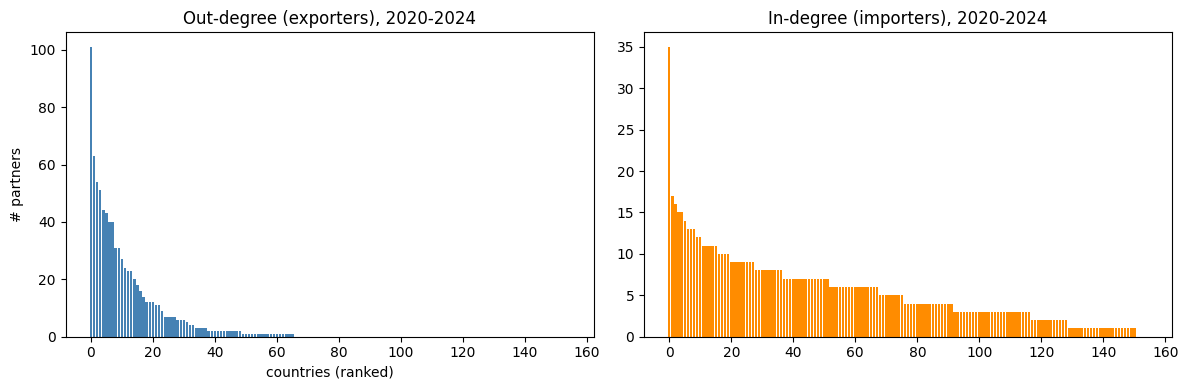

In [ ]:
import matplotlib.pyplot as plt

def degree_plot(data, window):
    gd = build_directed(data, window)
    outd = sorted(gd.outdegree(), reverse=True)
    ind  = sorted(gd.indegree(),  reverse=True)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].bar(range(len(outd)), outd, color="steelblue")
    ax[0].set_title(f"Out-degree (exporters), {window}")
    ax[0].set_xlabel("countries (ranked)"); ax[0].set_ylabel("# partners")
    ax[1].bar(range(len(ind)), ind, color="darkorange")
    ax[1].set_title(f"In-degree (importers), {window}")
    plt.tight_layout(); plt.show()

degree_plot(df, "2020-2024")

The degree distribution reveals a star-like (core-periphery) structure: a few hub exporters with very high out-degree and a large number of importers with low in-degree. This is why community detection might yield low modularity.

###  Resolution sweep

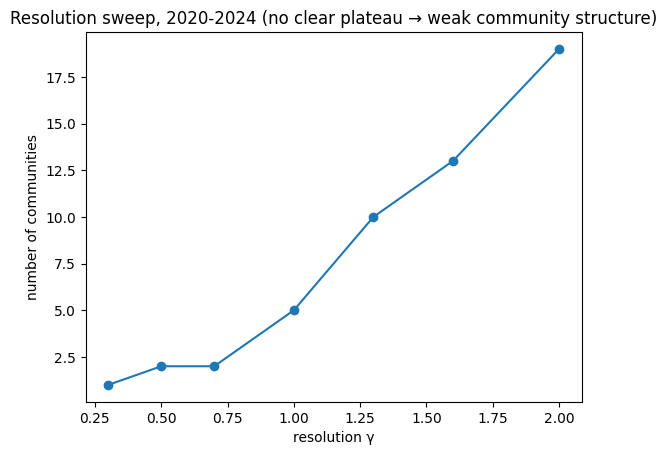

In [ ]:
def sweep_plot(data, window, resolutions=[0.3,0.5,0.7,1.0,1.3,1.6,2.0]):
    g = build_undirected(data, window)
    n = [len(g.community_multilevel(resolution=r)) for r in resolutions]
    plt.plot(resolutions, n, "o-")
    plt.xlabel("resolution γ"); plt.ylabel("number of communities")
    plt.title(f"Resolution sweep, {window} (no clear plateau → weak community structure)")
    plt.show()

sweep_plot(df, "2020-2024")

The only stable region is the degenerate split into two giant communities (γ ≈ 0.5–0.75). At any substantive number of communities the count grows with γ with no stable plateau. This indicates the absence of well-defined modular structure beyond a coarse two-way division, so we use the default γ = 1.0, which yields an interpretable number of groups.